<a href="https://colab.research.google.com/github/asukuabdulsamad/asuku-tutorials/blob/main/asuku_openmc_tutorials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")

In [8]:
# Install OpenMC
!pip install openmc

import openmc
print("Running OpenMC:", openmc.__version__)

# Download nuclear data
!wget -O endfb71.tar.xz https://anl.box.com/shared/static/uhbxlrx7hvxqw27psymfbhi7bx7s6u6a.xz

# Extract
!tar -xf endfb71.tar.xz

# Verify installation
import os
path = "/content/endfb-viii.0-hdf5/cross_sections.xml"

if not os.path.isfile(path):
    raise ValueError("Cross section installation failed!")
else:
    print("Installation completed")

# 🔥 IMPORTANT: Set for OpenMC
openmc.config['cross_sections'] = path

print("Cross sections set to:", openmc.config['cross_sections'])

Running OpenMC: 0.15.2
--2026-03-31 14:29:17--  https://anl.box.com/shared/static/uhbxlrx7hvxqw27psymfbhi7bx7s6u6a.xz
Resolving anl.box.com (anl.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to anl.box.com (anl.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/uhbxlrx7hvxqw27psymfbhi7bx7s6u6a.xz [following]
--2026-03-31 14:29:17--  https://anl.box.com/public/static/uhbxlrx7hvxqw27psymfbhi7bx7s6u6a.xz
Reusing existing connection to anl.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://anl.app.box.com/public/static/uhbxlrx7hvxqw27psymfbhi7bx7s6u6a.xz [following]
--2026-03-31 14:29:17--  https://anl.app.box.com/public/static/uhbxlrx7hvxqw27psymfbhi7bx7s6u6a.xz
Resolving anl.app.box.com (anl.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to anl.app.box.com (anl.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting respo

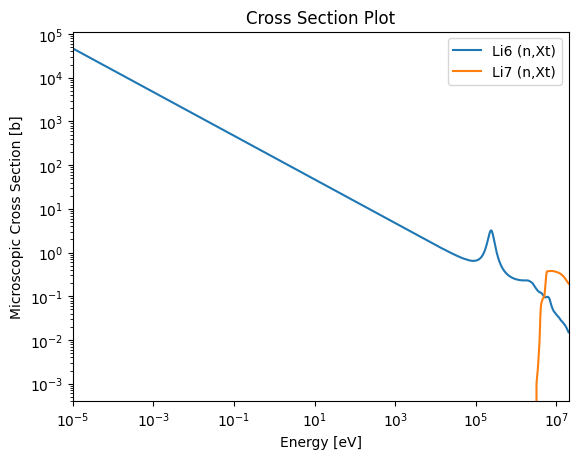

In [9]:
import matplotlib.pyplot as plt

fig = openmc.plotter.plot_xs(
    reactions = {
        'Li6': ['(n,Xt)'],
        'Li7': ['(n,Xt)'],
    }
)
plt.show()

# Note the axis are log scale